# Examples of lorenz equation discovery with EPDE framework

This notebook presents an overview of the evolutionary discovery of the burgers equation with the EPDE framework.

In [1]:
import numpy as np
import pandas as pd
import os
import sys
from typing import Union, Callable

import matplotlib.pyplot as plt
import matplotlib as mpl

Add some necessary imports

In [2]:
import sys
sys.path.append('..')
import epde
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['text.usetex'] = False

SMALL_SIZE = 12
mpl.rc('font', size=SMALL_SIZE)
mpl.rc('axes', titlesize=SMALL_SIZE)

# Lorenz equation introduction.

Lorenz equation — a compact model describing a chaotic dynamical system in three-dimensional space, combining linear relaxation and nonlinear coupling in a single system of ordinary differential equations:

$$
\begin{cases}
\dfrac{dx}{dt} = \sigma(y - x) \\[4pt]
\dfrac{dy}{dt} = x(\rho - z) - y \\[4pt]
\dfrac{dz}{dt} = xy - \beta z
\end{cases} \tag{1}
$$

where:

- $x(t), y(t), z(t)$ — the unknown coordinate functions (the position of a phase-space point at time $t$, whose trajectory traces out the attractor);
- $t$ — time;
- $\sigma, \rho, \beta$ — the three control parameters, governing the shape and behavior of the system.

**Where it comes from.** The system was derived by Edward Lorenz in 1963 as a drastically simplified model of atmospheric convection, obtained by truncating the equations of fluid flow to just three variables.

**Example solution.** Unlike Burgers' equation, this system has no closed-form analytical solution — the nonlinear coupling between $x$, $y$, and $z$ (in particular the $xz$ and $xy$ terms) makes it analytically intractable. To generate data we will instead integrate the system numerically (e.g. with a Runge–Kutta scheme), starting from an initial condition near the origin:

$$
(x_0, y_0, z_0) = (1,\ 1,\ 1), \tag{2}
$$

using the standard parameter values

You can see illustration of this equation solution below


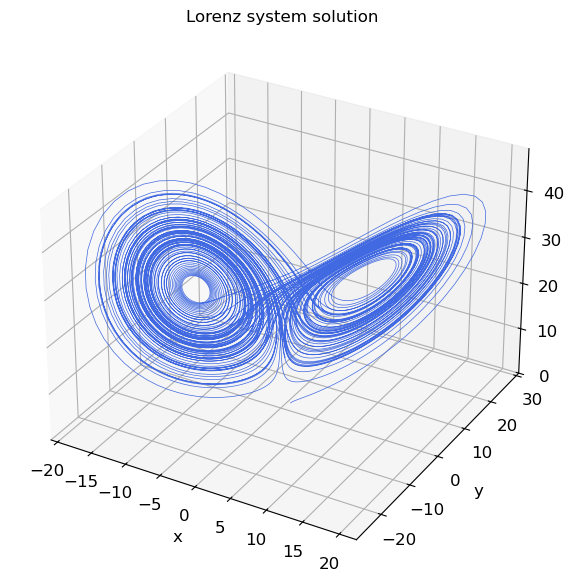

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

sigma, rho, beta = 10.0, 28.0, 8.0 / 3.0

def lorenz_rhs(state, sigma, rho, beta):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz])

def rk4_step(state, dt, sigma, rho, beta):
    k1 = lorenz_rhs(state, sigma, rho, beta)
    k2 = lorenz_rhs(state + dt/2 * k1, sigma, rho, beta)
    k3 = lorenz_rhs(state + dt/2 * k2, sigma, rho, beta)
    k4 = lorenz_rhs(state + dt * k3, sigma, rho, beta)
    return state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

dt = 0.01
n_steps = 10000
state0 = np.array([1.0, 1.0, 1.0])

trajectory = np.zeros((n_steps, 3))
trajectory[0] = state0

state = state0.copy()
for i in range(1, n_steps):
    state = rk4_step(state, dt, sigma, rho, beta)
    trajectory[i] = state

x_vals = trajectory[:, 0]
y_vals = trajectory[:, 1]
z_vals = trajectory[:, 2]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
ax.plot(x_vals, y_vals, z_vals, lw=0.5, color='royalblue')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Lorenz system solution')
fig.tight_layout()
plt.show()

To illustrate EPDE algorithm we will use syntethic data from file

In [8]:
t_file = "../projects/pic/data/lorenz/t.npy"
t = np.load(t_file)
data_file = "../projects/pic/data/lorenz/lorenz.npy"
data = np.load(data_file)
end = 1000
t = t[:end]
x = data[:end, 0]
y = data[:end, 1]
z = data[:end, 2]

After that we shall initialize equation search object.

In [10]:
from epde.interface.interface import EpdeSearch
epde_search_obj = EpdeSearch(use_solver=False, multiobjective_mode=True, use_pic=True, boundary=(100),
                            coordinate_tensors=[t, ], verbose_params={'show_iter_idx': True},
                            device='cpu')

setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x00000214A1A75D30>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x00000214A1A75D30>


Here you can see the explanation of parametrs in EpdeSearch creation:
   -  ``use_solver = False`` — skip the automatic PDE solver when scoring candidate equations; faster, less precise fitness estimate
   - ``multiobjective_mode = True`` — run MOEADD multi-objective search: Pareto front by Discrepancy (quality) + Instability
   - ``use_pic = True`` — define second pareto axis = Instability
   - ``boundary = 100`` — ignore this many grid points from each edge of the domain when computing derivatives
   - ``coordinate_tensors = [t, ]`` — grid coordinate tensors (from np.meshgrid) matching the data array
   - ``device = 'cpu'`` — device for torch computations

In [11]:
epde_search_obj.set_preprocessor(default_preprocessor_type='FD',
                                     preprocessor_kwargs={})

popsize = 20
epde_search_obj.set_moeadd_params(population_size=popsize, training_epochs=3)



In the cell above we define data preprocessor settings( preprocessing without data smoothing, finite derive calculation).
Additional parameters will be population size and number of optimziation epochs: ``training_epochs = 3``.

In [13]:
factors_max_number = {'factors_num': [1, 2], 'probas' : [0.8, 0.2]}


epde_search_obj.fit(data=[x, y, z], variable_names=['u', 'v', 'w'], max_deriv_order=(1,),
                    equation_terms_max_number=5, data_fun_pow=3, additional_tokens=[ ], #trig_tokens
                    equation_factors_max_number=factors_max_number)  #


Deriv orders after definition [[0]]
initial_shape (800,) derivs_tensor.shape (800, 1)
Size of linked labels is 2
Deriv orders after definition [[0]]
initial_shape (800,) derivs_tensor.shape (800, 1)
Size of linked labels is 4
Deriv orders after definition [[0]]
initial_shape (800,) derivs_tensor.shape (800, 1)
Size of linked labels is 6
The cardinality of defined token pool is [1 1 1 1 1 1]
Among them, the pool contains [1 1 1 1 1 1]
self.vars_demand_equation {'w', 'v', 'u'}
best_obj 6

========== Initial population ==========
[0.7244072  0.75268077 0.80863946 3.57658454 2.94008998 3.19055402]
[0.38918122 0.19649524 0.87986392 0.20450455 0.01691118 2.69882689]
[0.38918122 0.78472548 0.87986392 0.20450455 3.22829739 2.69882689]
[0.55363074 0.90642423 0.14862765 0.27430632 2.88685838 0.04045328]
[0.0991973  0.19649524 0.49435485 0.01613237 0.01691118 0.27035617]
[2.77989210e-05 8.32403488e-01 8.79863922e-01 9.21036559e-10
 2.35454033e+00 2.69882689e+00]
[2.77989210e-05 5.69030375e-01 5.5

Here you can see the explanation of parametrs parametr in fit method:
 - argument ``data`` desctibes array of data grid([x, y, z])
 - argument ``variable_names`` sets names of target variables
 - argument ``max_deriv_order`` sets the highest order of derivatives, that can be used in equation search
- number of terms, accepted into the structure before regularization is regulated by argument ``equation_terms_max_number``
- argument ``equation_factors_max_number`` defines number of terms in the term can be set as integer (in this case, one number factor will apear in equation with 0.8 probability and two number factor appear with 0.2 probability)
- argument ``additional_tokens`` sets tokens, hat would be used to construct the equations among the main variables and their derivatives
- argument ``data_fun_pow`` describes maximum power of token


The discovered equations can be accessed with ``EpdeSearch.equations()`` method. If the ``only_print = True``, than the equations will be printed in their text forms. 

Otherwise, they will be return: if the followup argument ``only_str`` is ``True``, than the equations are returned only in their symbolic string-form. If ``only_str = False``, than the equation in its program implementation ``epde.structure.main_structures.SoEq`` are returned.

Additional parametr ``num = 3`` define number of poretto-levels for printing

In [15]:
epde_search_obj.equations(only_print=True, num = 1)



0-th non-dominated level


 / 9.999761807902091 * v{power: 1.0} + -9.999760285509664 * u{power: 1.0} + 0.0 = du/dx0{power: 1.0}
 | -0.9503286754755157 * u{power: 1.0} * w{power: 1.0} + 25.439535184718906 * u{power: 1.0} + 0.0 = dv/dx0{power: 1.0}
 \ 23.350209836144803 * v{power: 1.0} + -21.51715326161397 * u{power: 1.0} + 7.3680157273763465 * w{power: 1.0} + -159.1194836578434 = dw/dx0{power: 1.0}
{'max_terms_number': {'optimizable': False, 'value': 5}, 'max_factors_in_term': {'optimizable': False, 'value': {'factors_num': [1, 2], 'probas': [0.8, 0.2]}}, ('sparsity', 'w'): {'optimizable': True, 'value': np.float64(0.064052733554315)}, ('sparsity', 'v'): {'optimizable': True, 'value': np.float64(0.00011304906391216154)}, ('sparsity', 'u'): {'optimizable': True, 'value': np.float64(0.003687759575759163)}} , with objective function values of [2.77989210e-05 4.20948395e-02 1.30185714e-01 9.21036559e-10
 1.22607567e-03 1.74667139e-02] 

 / 9.999761807902091 * v{power: 1.0} + -9.9997602855

We can use visual analysis of the Pareto-optimal set of candidate equations, placed in the complexity-quality criteria space, to select the optimal equation. Method ``EpdeSearch.visualize_solutions()`` illustrates the first non-dominated set of solutions (i.e. Pareto frontier).

Vizualize_solutions method presents three graphics for all target variables(u, v, w)

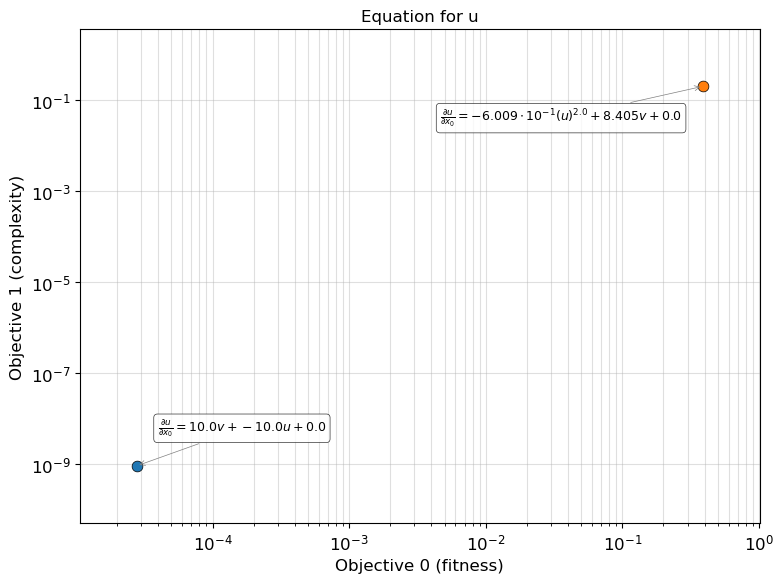

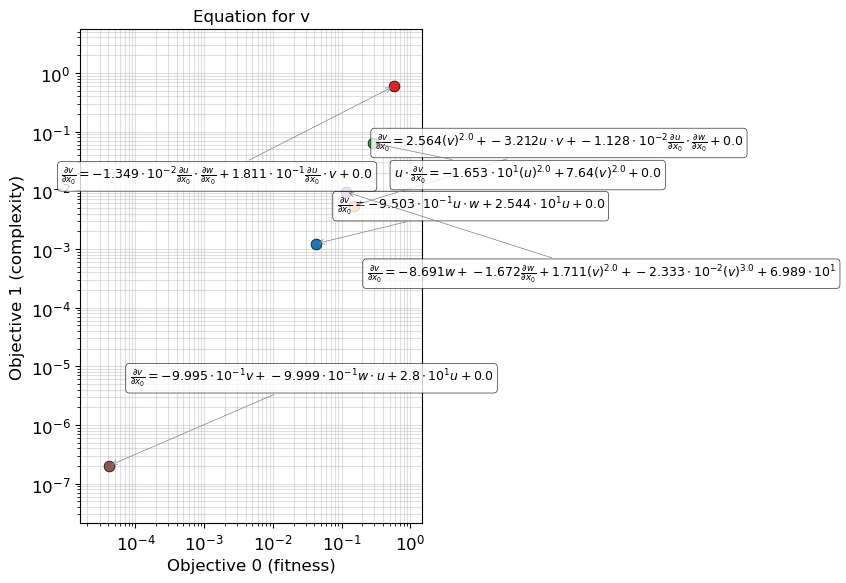

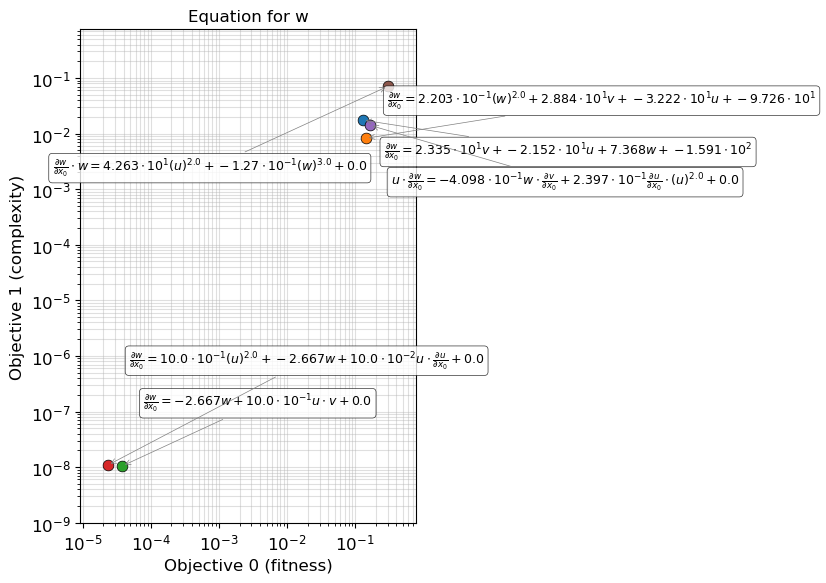

[<Figure size 800x600 with 1 Axes>,
 <Figure size 800x600 with 1 Axes>,
 <Figure size 800x600 with 1 Axes>]

In [16]:
epde_search_obj.visualize_solutions()